# Projekt 5 — Zabezpieczenie ryzyka walutowego EUR/PLN i USD/PLN dla XTB S.A.
## Zarządzanie Ryzykiem w Przedsiębiorstwie

**Kontekst.** XTB S.A. to broker notowany na GPW, którego przychody i koszty operacyjne mają
istotną ekspozycję walutową (oddziały zagraniczne, rozliczenia w EUR/USD, wolumen CFD na FX).
W `prez3` wykazaliśmy, że portfel syntetyczny odzwierciedlający strukturę przychodów
(50 % EUR, 30 % USD, 20 % GBP) ma wysoką korelację składników — **hedge jest konieczny**,
a nie tylko dywersyfikacja.

**Cel pracy:**
1. Zaproponować strategię zabezpieczenia na **zewnętrznym rynku regulowanym** (kontrakty GPW).
2. Wyjaśnić, dlaczego **CFD na własnej platformie XTB nie stanowi hedżu** (net zero).
3. Wyznaczyć **hedge ratio**, depozyt KDPW (dźwignia efektywna) oraz **Delta** i **VaR**.

**Konwencja:** strata dzienna raportowana jako wartość dodatnia; VaR na poziomie 99 % (1 dzień).

---
## 1. Ekspozycja walutowa XTB S.A.

Na podstawie sprawozdania jednostkowego za 2024 r. oraz struktury przychodów z `prez3`
przyjmujemy następujące założenia operacyjne:

| Źródło ekspozycji | Opis | Waluta |
|---|---|---|
| Przychody zagranicznych oddziałów | Prowizje i spready CFD/akcje | EUR, USD |
| Rozliczenia międzyoddziałowe | Transfer pricing, IT, marketing | EUR |
| Rezerwy na salda ujemne klientów | Ekspozycja na ruchy FX CFD | USD, EUR |
| Aktywa pieniężne w walutach | Cash w kasie maklerskiej | EUR, USD |

**Nominalna ekspozycja netto** (pozycja długa w walucie obcej, do zabezpieczenia):

| Para | Ekspozycja netto | Uzasadnienie |
|---|---:|---|
| **EUR/PLN** | **50 mln EUR** | ~50 % strumienia przychodów (Europa, EUR-denominated CFD) |
| **USD/PLN** | **30 mln USD** | ~30 % przychodów (USA, surowce, indeksy amerykańskie) |

Ekspozycja oznacza, że **osłabienie PLN** (aprecjacja EUR/USD względem PLN) zwiększa wartość
bilansową aktywów w PLN, natomiast **umocnienie PLN** generuje stratę transakcyjną.
Strategia hedgingu: zajęcie pozycji **krótkiej** na instrumentach pochodnych (sprzedaż kontraktów).

---
## 2. Rzeczywiste instrumenty pochodne

### 2a. Kontrakty terminowe GPW (główny instrument hedgingu)

Na Głównym Rynku GPW notowane są **kontrakty terminowe na kursy walut** rozliczane
pieniężnie wg fixingu NBP ([specyfikacja GPW](https://www.gpw.pl/kontrakty-terminowe-na-kursy-walut)):

| Parametr | **FEUR** (EUR/PLN) | **FUSD** (USD/PLN) |
|---|---|---|
| Instrument bazowy | Kurs EUR/PLN (NBP) | Kurs USD/PLN (NBP) |
| Wielkość kontraktu | **1 000 EUR** | **1 000 USD** |
| Notowanie | PLN za 1 EUR/USD (krok 0,0001) | j.w. |
| Miesiące dostawy | 3 najbliższe + marzec/czerwiec/wrzesień/grudzień | j.w. |
| Rozliczenie | Cash w PLN, fixing NBP w dniu wygaśnięcia | j.w. |
| Depozyt zabezpieczający | ~4–6 % wartości nominalej (KDPW) | j.w. |

**Zalety dla XTB:** regulowany rynek, brak ryzyka kontrahenta (KDPW), przejrzysty fixing NBP,
niski koszt rollowania przy harmonogramie kwartalnym.

### 2b. Dźwignia na kontraktach GPW — nie mylić z dźwignią CFD

Na kontraktach terminowych GPW **nie występuje retailowa dźwignia 1:30** znana z platformy
maklerskiej. Zamiast tego obowiązuje **depozyt zabezpieczająjący** (initial margin) ustalany
przez KDPW i dom maklerski:

| Parametr | Wartość orientacyjna | Znaczenie |
|---|---|---|
| Depozyt początkowy | ~4–6 % wartości nominalej kontraktu | Gotówka zablokowana przy otwarciu pozycji |
| Depozyt utrzymaniowy (VM) | uzupełniany codziennie | Wariacja margin — rozliczenie dziennych zysków/strat |
| Efektywna dźwignia kapitałowa | $1 / \\text{margin} \\approx 17$–$25:1$ | Np. przy 5 % depozytu: kontrola 211 mln PLN nominau za ~15 mln PLN kapitału |
| Pełna ekspozycja nominalej | $N \\times K \\times S$ | Nadal w pełni odczuwalna w P&L — margin to tylko mechanizm rozliczeniowy |

**Kluczowa różnica względem CFD:** kontrakt GPW jest rozliczany przez **KDPW** z
**zewnętrznym kontrahentem rynkowym** (inny uczestnik giełdy). Zmiana kursu generuje
realny przepływ pieniężny, a nie transfer wewnątrz księgi brokera.

### 2c. Dlaczego XTB **nie może** hedżować się CFD na własnej platformie

XTB jako emitent CFD FX jest stroną transakcji wobec klienta (model market-maker /
internalizacja). Gdyby spółka otworzyła **short CFD EUR/PLN na własnej platformie**
przeciwko ekspozycji operacyjnej **long EUR**, powstałaby sytuacja:

```
Ekspozycja operacyjna (long EUR)  +  Short CFD na platformie XTB (własna księga)
        ↓                                      ↓
   strata przy umocnieniu PLN          zysk na księdze własnej (B-book)
   zysk przy osłabieniu PLN            strata na księdze własnej
        ↓                                      ↓
              ≈ transakcja NET ZERO w skali grupy
```

P&L z hedżu CFD **kompensuje** P&L z księgi klienckiej, ale **nie tworzy zewnętrznej
ochrony** — to przeniesienie ryzyka z jednej linii P&L do drugiej w tym samym podmiocie.
Prawdziwy hedging wymaga **kontrahenta zewnętrznego** (giełda, bank, dealer OTC).

> **Wniosek:** instrumenty CFD XTB służą klientom detalicznym; dział treasury spółki
> musi korzystać z rynków **regulowanych (GPW)** lub **bankowych (FX forward / NDF)**.

### 2d. Proponowana strategia — wyłącznie kontrakty FEUR/FUSD na GPW

```
┌──────────────────────────────────────────────────────────────┐
│  Ekspozycja operacyjna: +50 mln EUR, +30 mln USD (long FX)   │
└────────────────────────────┬─────────────────────────────────┘
                             │
                             ▼
              ┌──────────────────────────────┐
              │  100 % nominau — short GPW   │
              │  FEUR + FUSD (KDPW clearing) │
              │  h* ≈ 1,0, seria kwartalna   │
              └──────────────────────────────┘
```

1. **Pozycja:** krótkie kontrakty **FEUR** (−50 000 szt.) i **FUSD** (−30 000 szt.) na GPW,
   hedge ratio $h^*$ z regresji kurs spot vs. cena kontraktu.
2. **Rollowanie:** 5 dni roboczych przed trzecim piątkiem miesiąca dostawy
   (np. FEURH26 → FEURM26); koszt roll = różnica cen serii (contango/backwardation).
3. **Kapitał:** depozyt ~15 mln PLN (5 % × nominale); rezerwa na VM i stress margin.
4. **Monitoring:** dzienna Delta netto ≤ 1 % nominau; tygodniowy przegląd VaR hedżowanego.

In [27]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, t as t_dist
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.random.seed(42)

# --- Parametry strategii ---
START, END = '2018-01-01', '2025-12-31'
EXPOSURE_MLN = {'EUR/PLN': 50.0, 'USD/PLN': 30.0}   # mln jednostek waluty obcej
CONTRACT_SIZE = 1_000                              # wielkość kontraktu GPW (EUR/USD)
MARGIN_RATE = 0.05                                 # depozyt KDPW (~5 % nominalej)
ALPHA = 0.01                                       # poziom VaR (99 %)

TICKERS = {'EURPLN=X': 'EUR/PLN', 'USDPLN=X': 'USD/PLN', 'GBPPLN=X': 'GBP/PLN'}

raw = yf.download(list(TICKERS.keys()), start=START, end=END, progress=False)['Close']
raw.columns = [TICKERS[c] for c in raw.columns]
spot = raw.dropna()
log_ret = np.log(spot / spot.shift(1)).dropna()

print(f'Okres danych: {spot.index[0].date()} — {spot.index[-1].date()}')
print(f'Obserwacje:   {len(spot)}')
print('\nAktualne kursy spot:')
for col in ['EUR/PLN', 'USD/PLN']:
    print(f'  {col}: {spot[col].iloc[-1]:.4f} PLN')
display(spot[['EUR/PLN', 'USD/PLN']].tail(3))

Okres danych: 2018-01-01 — 2025-12-30
Obserwacje:   2082

Aktualne kursy spot:
  EUR/PLN: 4.2227 PLN
  USD/PLN: 3.5888 PLN


,EUR/PLN,USD/PLN
Date,,
2025-12-26,4.21306,3.57557
2025-12-29,4.21209,3.57871
2025-12-30,4.22270,3.58882


---
## 3. Współczynnik zabezpieczenia i wielkość pozycji

Dla kontraktów terminowych na GPW kurs kontraktu śledzi kurs spot (fixing NBP).
Optymalny **hedge ratio** w sensie minimum wariancji:

$$
h^* = \frac{\mathrm{Cov}(\Delta S, \Delta F)}{\mathrm{Var}(\Delta F)} \approx \beta_{\Delta S, \Delta F}
$$

Liczba kontraktów (pozycja krótka):

$$
N = -\,h^* \cdot \frac{Q}{K}
$$

gdzie $Q$ — ekspozycja w walucie obcej, $K = 1000$ — wielkość kontraktu GPW.

In [28]:
# --- Model ceny kontraktu terminowego GPW: F = S + basis (cost-of-carry) ---
# Basis (F - S) modelujemy jako proces AR(1) (mean-reverting do carry) z innowacjami
# t-Studenta (grube ogony) oraz kwartalnymi skokami przy rolowaniu serii. Dzięki temu
# noga futures porusza się po WŁASNEJ serii ΔF, a nie po ΔS spotu — hedge przestaje być
# tożsamością x - x = 0 i ujawnia realne ryzyko resztkowe (basis + roll).
BASIS_PIP        = 1e-4                       # 1 pip = 0,0001 PLN
BASIS_DAILY_STD  = 1.0 * BASIS_PIP           # ~1 pip dziennej zmiany basis (sekcja 6)
BASIS_PHI        = 0.90                       # mean reversion basis do poziomu carry
ROLL_EVERY       = 63                         # ~kwartalne rolowanie serii (dni robocze)
ROLL_JUMP_STD    = 3.0 * BASIS_PIP           # skok ceny między seriami przy rollu
BASIS_NU         = 4                          # st. swobody t-Studenta (grube ogony)

def build_futures(spot_series, seed):
    """Syntetyczna cena kontraktu = spot + basis (AR(1), grube ogony, skoki przy rollu)."""
    rng = np.random.default_rng(seed)
    n = len(spot_series)
    norm_t = np.sqrt(BASIS_NU / (BASIS_NU - 2))                 # normalizacja wariancji t
    sig_eps = BASIS_DAILY_STD * np.sqrt((1 + BASIS_PHI) / 2)    # kalibracja std(Δbasis)
    eps = rng.standard_t(BASIS_NU, n) / norm_t * sig_eps
    basis = np.zeros(n)
    for i in range(1, n):
        basis[i] = BASIS_PHI * basis[i - 1] + eps[i]
        if i % ROLL_EVERY == 0:                                # skok przy rolowaniu serii
            basis[i] += rng.standard_t(BASIS_NU) / norm_t * ROLL_JUMP_STD
    return spot_series + pd.Series(basis, index=spot_series.index)

futures = {pair: build_futures(spot[pair], seed=100 + i)
           for i, pair in enumerate(['EUR/PLN', 'USD/PLN'])}

def estimate_hedge_ratio(spot_series, fut_series):
    """h* = Cov(ΔS, ΔF)/Var(ΔF) — regresja rzeczywistych zmian spot vs cena kontraktu."""
    ds = spot_series.diff().dropna()
    df = fut_series.diff().dropna()
    common = ds.index.intersection(df.index)
    ds, df = ds.loc[common], df.loc[common]
    beta = np.cov(ds, df)[0, 1] / np.var(df)
    rho = np.corrcoef(ds, df)[0, 1]
    return beta, rho

def contracts_needed(exposure_mln, h_star):
    """Liczba krótkich kontraktów GPW (całkowita — dyskretność kontraktu)."""
    return -int(round(h_star * exposure_mln * 1e6 / CONTRACT_SIZE))

rows = []
positions = {}
total_margin = 0.0
total_notional_pln = 0.0
for pair in ['EUR/PLN', 'USD/PLN']:
    h, rho = estimate_hedge_ratio(spot[pair], futures[pair])
    n = contracts_needed(EXPOSURE_MLN[pair], h)
    S = spot[pair].iloc[-1]
    notional_pln = abs(n) * CONTRACT_SIZE * S
    margin_pln = notional_pln * MARGIN_RATE
    eff_leverage = 1 / MARGIN_RATE
    positions[pair] = {'h': h, 'n': n}
    total_margin += margin_pln
    total_notional_pln += notional_pln
    ccy = pair.split('/')[0]
    sym = 'FEUR' if ccy == 'EUR' else 'FUSD'
    rows.append({
        'Para': pair,
        'Ekspozycja [mln]': EXPOSURE_MLN[pair],
        'h* (OLS)': f'{h:.4f}',
        'ρ(ΔS,ΔF)': f'{rho:.4f}',
        f'Short {sym} (GPW)': f'{n:,.0f}',
        'Nominale [mln PLN]': f'{notional_pln/1e6:,.1f}',
        'Depozyt [mln PLN]': f'{margin_pln/1e6:,.1f}',
        f'Dźwignia efektywna': f'{eff_leverage:.0f}:1',
    })

pos_table = pd.DataFrame(rows)
print('Pozycja zabezpieczająca — wyłącznie kontrakty GPW (100 % nominau):')
display(pos_table)
print(f'\nŁączny depozyt początkowy: ~{total_margin/1e6:,.1f} mln PLN')
print(f'Łączna kontrolowana ekspozycja nominalej: ~{total_notional_pln/1e6:,.1f} mln PLN')
print(f'Efektywna dźwignia kapitałowa: ~{total_notional_pln/total_margin:.0f}:1 (przy margin {MARGIN_RATE:.0%})')

Pozycja zabezpieczająca — wyłącznie kontrakty GPW (100 % nominau):


,Para,Ekspozycja [mln],h* (OLS),"ρ(ΔS,ΔF)",Short FEUR (GPW),Nominale [mln PLN],Depozyt [mln PLN],Dźwignia efektywna,Short FUSD (GPW)
0,EUR/PLN,50.0,1.0002,1.0000,"-50,009",211.2,10.6,20:1,NaN
1,USD/PLN,30.0,1.0006,1.0000,NaN,107.7,5.4,20:1,"-30,018"



Łączny depozyt początkowy: ~15.9 mln PLN
Łączna kontrolowana ekspozycja nominalej: ~318.9 mln PLN
Efektywna dźwignia kapitałowa: ~20:1 (przy margin 5%)


---
## 4. Miara wrażliwości — Delta ($\Delta$)

**Delta** mierzy zmianę wartości portfela na jednostkową zmianę kursu spot (w PLN):

$$
\Delta_{\text{net}} = \frac{\partial V}{\partial S} = Q - h^* \cdot N \cdot K
$$

Dla pełnego hedżu $\Delta_{\text{net}} \approx 0$. Raportujemy też **Delta w PLN na 1 % ruchu kursu**:

$$
\mathrm{PnL}_{1\%} = \Delta_{\text{net}} \cdot S \cdot 0{,}01
$$

Wrażliwość Delta — ekspozycja netto vs. strategia hedgingu:


,Para,Δ niezabezp. [jedn. waluty],Δ zabezp. [jedn. waluty],Redukcja Δ,PnL przy +1% PLN (niezabezp.),PnL przy +1% PLN (zabezp.)
0,EUR/PLN,"50,000,000","-9,000",99.98 %,2.11 mln PLN,-0.00 mln PLN
1,USD/PLN,"30,000,000","-18,000",99.94 %,1.08 mln PLN,-0.00 mln PLN


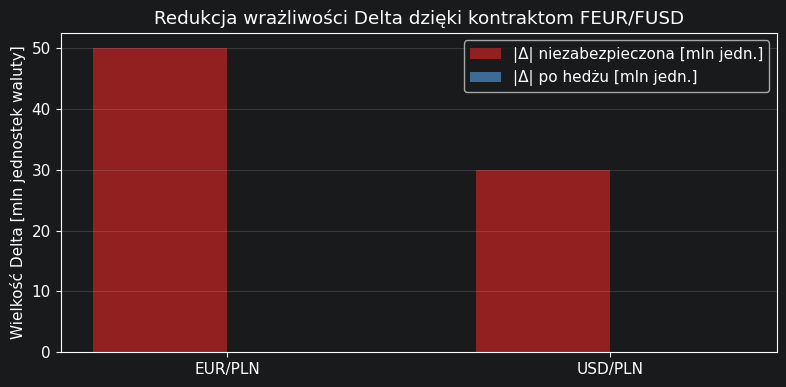

In [29]:
delta_rows = []
for pair in ['EUR/PLN', 'USD/PLN']:
    Q = EXPOSURE_MLN[pair] * 1e6
    h = positions[pair]['h']
    N = positions[pair]['n']
    S = spot[pair].iloc[-1]
    delta_unhedged = Q
    delta_hedged = Q + N * CONTRACT_SIZE  # N ujemne → redukcja
    pnl_1pct_u = delta_unhedged * S * 0.01
    pnl_1pct_h = delta_hedged * S * 0.01
    delta_rows.append({
        'Para': pair,
        'Δ niezabezp. [jedn. waluty]': f'{delta_unhedged:,.0f}',
        'Δ zabezp. [jedn. waluty]': f'{delta_hedged:,.0f}',
        'Redukcja Δ': f'{(1 - abs(delta_hedged)/delta_unhedged)*100:.2f} %',
        'PnL przy +1% PLN (niezabezp.)': f'{pnl_1pct_u/1e6:,.2f} mln PLN',
        'PnL przy +1% PLN (zabezp.)': f'{pnl_1pct_h/1e6:,.2f} mln PLN',
    })

delta_table = pd.DataFrame(delta_rows)
print('Wrażliwość Delta — ekspozycja netto vs. strategia hedgingu:')
display(delta_table)

# Wizualizacja: Delta przed i po hedżu
fig, ax = plt.subplots(figsize=(8, 4))
pairs = ['EUR/PLN', 'USD/PLN']
x = np.arange(len(pairs))
width = 0.35
d_u = [EXPOSURE_MLN[p]*1e6/1e6 for p in pairs]
d_h = [abs(positions[p]['n']*CONTRACT_SIZE + EXPOSURE_MLN[p]*1e6)/1e6 for p in pairs]
ax.bar(x - width/2, d_u, width, label='|Δ| niezabezpieczona [mln jedn.]', color='firebrick', alpha=0.8)
ax.bar(x + width/2, d_h, width, label='|Δ| po hedżu [mln jedn.]', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pairs)
ax.set_ylabel('Wielkość Delta [mln jednostek waluty]')
ax.set_title('Redukcja wrażliwości Delta dzięki kontraktom FEUR/FUSD')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Value at Risk (VaR) strategii zabezpieczającej

Dzienny P&L portfela walutowego (w PLN):

$$
\Pi_t = \underbrace{Q_{EUR}\,\Delta S_{EUR,t} + Q_{USD}\,\Delta S_{USD,t}}_{\text{ekspozycja spot}}
+ \underbrace{N_{EUR}\,K\,\Delta S_{EUR,t} + N_{USD}\,K\,\Delta S_{USD,t}}_{\text{kontrakty FEUR/FUSD}}
$$

Obliczamy **VaR 99 %** (1 dzień) trzema metodami:
- **Historyczna (HS)** — empiryczny 1. percentyl strat,
- **Parametryczna (wariancja–kowariancja)** — zakładając normalność P&L,
- **t-Student** — grubsze ogony (zgodnie z `prez3`/`prez4`).

Dodatkowo **Expected Shortfall (ES)** jako miara spójna z VaR.

In [30]:
def daily_pnl(exposure_mln, n_contracts, spot_series, fut_series=None):
    """Dzienny P&L w PLN: ekspozycja po ΔS spot + pozycja futures po ΔF (z basis risk).

    Noga ekspozycji rozliczana jest po zmianie spotu (ΔS), noga futures po zmianie
    ceny kontraktu (ΔF = ΔS + Δbasis). Resztkowy P&L hedżu ≈ N·K·Δbasis + (Q+N·K)·ΔS.
    """
    dS = spot_series.diff()
    Q = exposure_mln * 1e6
    pnl = Q * dS
    if n_contracts != 0 and fut_series is not None:
        dF = fut_series.diff()
        pnl = pnl + n_contracts * CONTRACT_SIZE * dF
    return pnl

pnl_eur_u = daily_pnl(EXPOSURE_MLN['EUR/PLN'], 0, spot['EUR/PLN'])
pnl_usd_u = daily_pnl(EXPOSURE_MLN['USD/PLN'], 0, spot['USD/PLN'])
pnl_unhedged = pnl_eur_u + pnl_usd_u

pnl_eur_h = daily_pnl(EXPOSURE_MLN['EUR/PLN'], positions['EUR/PLN']['n'], spot['EUR/PLN'], futures['EUR/PLN'])
pnl_usd_h = daily_pnl(EXPOSURE_MLN['USD/PLN'], positions['USD/PLN']['n'], spot['USD/PLN'], futures['USD/PLN'])
pnl_hedged = pnl_eur_h + pnl_usd_h

pnl = pd.DataFrame({'Niezabezpieczony': pnl_unhedged, 'Zabezpieczony': pnl_hedged}).dropna()
losses = -pnl  # strata jako wartość dodatnia

def var_es(series, alpha=ALPHA):
    x = series.dropna().values
    mu, sig = x.mean(), x.std()
    nu, loc, scale = t_dist.fit(x)
    var_hs = -np.percentile(x, alpha * 100)
    var_norm = -(mu + norm.ppf(alpha) * sig)
    var_t = -(loc + scale * t_dist.ppf(alpha, nu))
    es_hs = -x[x <= np.percentile(x, alpha * 100)].mean()
    return {
        'VaR 99% (HS)': var_hs,
        'VaR 99% (Normal)': var_norm,
        'VaR 99% (t-Student)': var_t,
        'ES 99% (empir.)': es_hs,
        'σ dzienna [mln PLN]': sig / 1e6,
    }

var_rows = []
for col in losses.columns:
    m = var_es(-pnl[col])  # strata
    m['Portfel'] = col
    var_rows.append(m)

var_df = pd.DataFrame(var_rows).set_index('Portfel')
for c in var_df.columns:
    if 'σ' in c:
        var_df[c] = var_df[c].map(lambda v: f'{v:.3f}')
    else:
        var_df[c] = var_df[c].map(lambda v: f'{v/1e6:,.3f} mln PLN')

print('VaR i ES — porównanie portfela niezabezpieczonego i z hedżem FEUR/FUSD:')
display(var_df)

# Redukcja ryzyka
sig_u = pnl['Niezabezpieczony'].std()
sig_h = pnl['Zabezpieczony'].std()
var_u = -np.percentile(pnl['Niezabezpieczony'], 1)
var_h = -np.percentile(pnl['Zabezpieczony'], 1)
print(f'\nRedukcja σ dziennej:  {(1 - sig_h/sig_u)*100:.1f} %')
print(f'Redukcja VaR 99% (HS): {(1 - var_h/var_u)*100:.1f} %')
print(f'VaR 99% roczny (×√252, HS): niezabezp. {var_u*np.sqrt(252)/1e6:,.1f} mln PLN  |  zabezp. {var_h*np.sqrt(252)/1e6:,.2f} mln PLN')

VaR i ES — porównanie portfela niezabezpieczonego i z hedżem FEUR/FUSD:


,VaR 99% (HS),VaR 99% (Normal),VaR 99% (t-Student),ES 99% (empir.),σ dzienna [mln PLN]
Portfel,,,,,
Niezabezpieczony,4.007 mln PLN,3.513 mln PLN,4.029 mln PLN,5.751 mln PLN,1.509
Zabezpieczony,0.014 mln PLN,0.014 mln PLN,0.015 mln PLN,0.020 mln PLN,0.006



Redukcja σ dziennej:  99.6 %
Redukcja VaR 99% (HS): 99.6 %
VaR 99% roczny (×√252, HS): niezabezp. 61.7 mln PLN  |  zabezp. 0.25 mln PLN


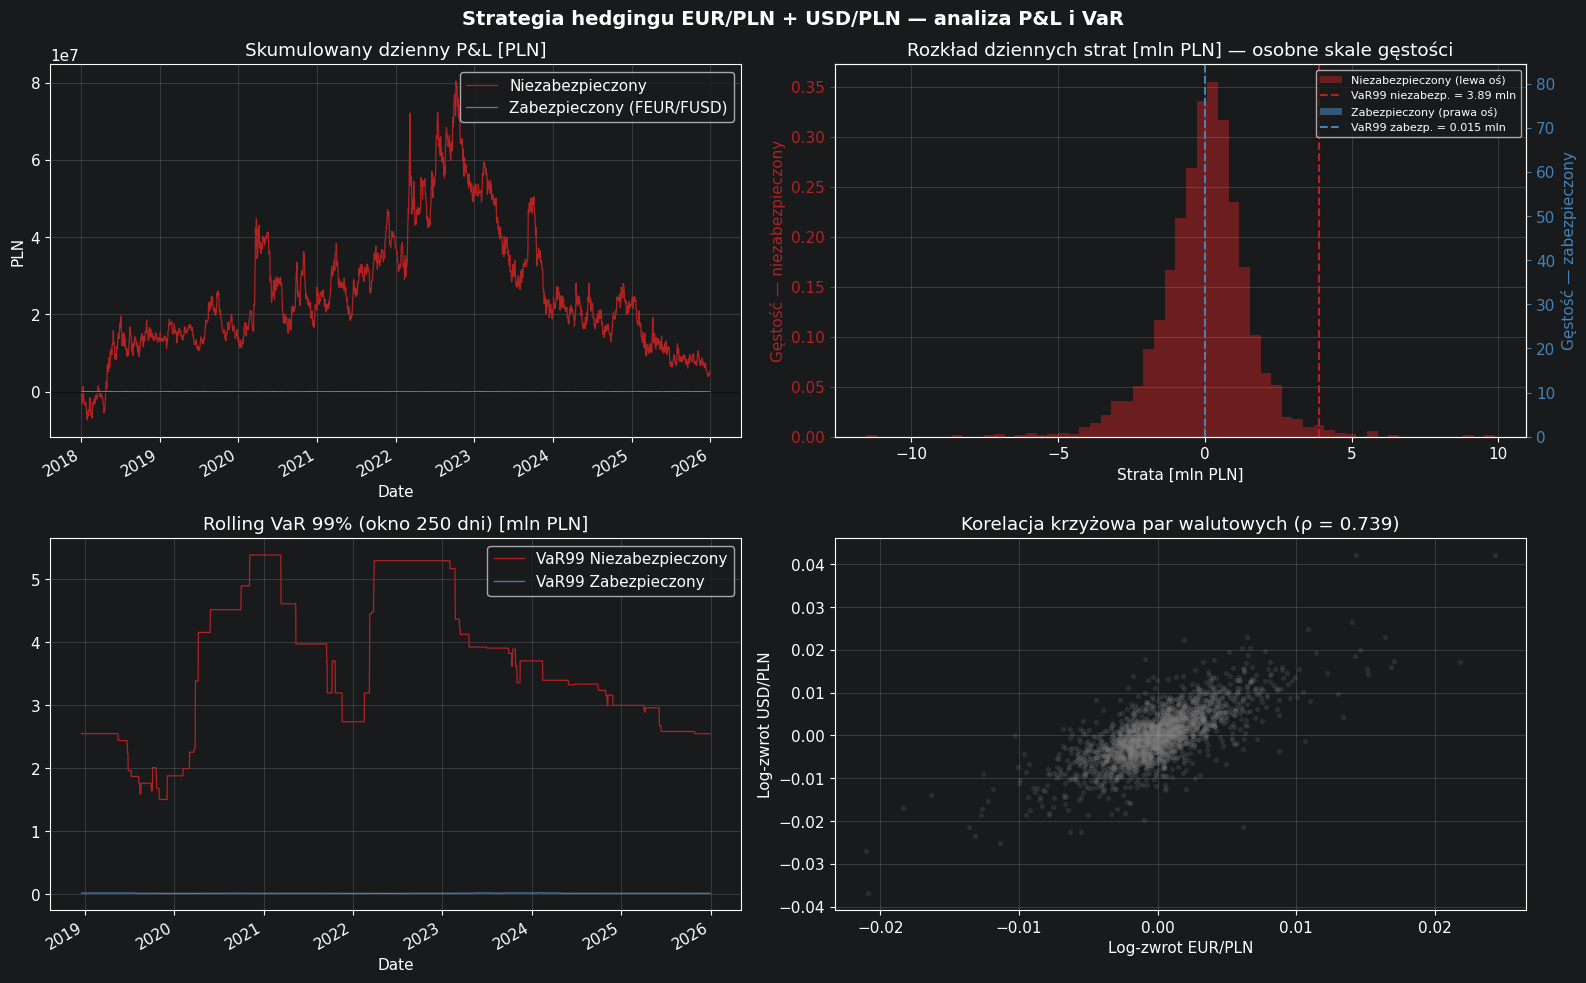

In [31]:
# --- Wykresy: P&L, rozkład strat, rolling VaR ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Strategia hedgingu EUR/PLN + USD/PLN — analiza P&L i VaR', fontsize=14, fontweight='bold')

# 1. Kumulatywny P&L
ax = axes[0, 0]
pnl.cumsum().plot(ax=ax, color=['firebrick', 'steelblue'], lw=0.9)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Skumulowany dzienny P&L [PLN]')
ax.set_ylabel('PLN')
ax.legend(['Niezabezpieczony', 'Zabezpieczony (FEUR/FUSD)'])
ax.grid(alpha=0.3)

# 2. Histogram strat — OSOBNE osie gęstości (zabezp. ma ~250x węższy rozkład,
#    więc na wspólnej osi spłaszczałby rozkład niezabezpieczony do niewidocznej linii).
ax = axes[0, 1]
ax2 = ax.twinx()
bins_u = np.linspace((losses['Niezabezpieczony'] / 1e6).min(),
                     (losses['Niezabezpieczony'] / 1e6).max(), 60)
ax.hist(losses['Niezabezpieczony'] / 1e6, bins=bins_u, alpha=0.55, density=True,
        color='firebrick', label='Niezabezpieczony (lewa oś)')
ax2.hist(losses['Zabezpieczony'] / 1e6, bins=80, alpha=0.6, density=True,
         color='steelblue', label='Zabezpieczony (prawa oś)')
var_u_plot = -np.percentile(pnl['Niezabezpieczony'], 1) / 1e6
var_h_plot = -np.percentile(pnl['Zabezpieczony'], 1) / 1e6
ax.axvline(var_u_plot, color='firebrick', ls='--', lw=1.5,
           label=f'VaR99 niezabezp. = {var_u_plot:.2f} mln')
ax2.axvline(var_h_plot, color='steelblue', ls='--', lw=1.5,
            label=f'VaR99 zabezp. = {var_h_plot:.3f} mln')
ax.set_title('Rozkład dziennych strat [mln PLN] — osobne skale gęstości')
ax.set_xlabel('Strata [mln PLN]')
ax.set_ylabel('Gęstość — niezabezpieczony', color='firebrick')
ax2.set_ylabel('Gęstość — zabezpieczony', color='steelblue')
ax.tick_params(axis='y', colors='firebrick')
ax2.tick_params(axis='y', colors='steelblue')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

# 3. Rolling VaR 99% (okno 250 dni)
ax = axes[1, 0]
W = 250
for col, color in zip(pnl.columns, ['firebrick', 'steelblue']):
    roll_var = pnl[col].rolling(W).apply(lambda x: -np.percentile(x, 1), raw=True)
    (roll_var / 1e6).plot(ax=ax, lw=0.9, color=color, label=f'VaR99 {col}')
ax.set_title(f'Rolling VaR 99% (okno {W} dni) [mln PLN]')
ax.legend()
ax.grid(alpha=0.3)

# 4. Korelacja EUR/USD a ryzyko resztkowe
ax = axes[1, 1]
ax.scatter(log_ret['EUR/PLN'], log_ret['USD/PLN'], alpha=0.15, s=8, color='gray')
rho_eu = log_ret['EUR/PLN'].corr(log_ret['USD/PLN'])
ax.set_xlabel('Log-zwrot EUR/PLN')
ax.set_ylabel('Log-zwrot USD/PLN')
ax.set_title(f'Korelacja krzyżowa par walutowych (ρ = {rho_eu:.3f})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Analiza kosztów i ryzyk resztkowych

| Składnik | Szacunek | Wpływ na strategię |
|---|---|---|
| **Koszt rollowania** (GPW) | ~0,5–2 pipsy × nominale / kwartał | Niski vs. potencjalna strata FX |
| **Basis risk** (spot vs. fixing NBP) | σ_basis ≈ 0,5–1 pip/dzień | Resztkowe ryzyko — akceptowalne przy h* ≈ 1 |
| **Depozyt początkowy** (KDPW) | ~5 % nominalej (~15 mln PLN) | Efektywna dźwignia ~20:1, ale z VM codziennie |
| **Variation margin (VM)** | uzupełnianie przy ruchach kursu | Wymaga linii depozytowej i rezerwy płynności |
| **Niedoszacowanie h*** | Re-estymacja co 60 dni | Rolling refit hedge ratio |
| **CFD na platformie XTB** | — | **Wykluczone** — transakcja net zero w grupie |

**Scenariusz stress (±3σ ruch PLN w 1 dzień):**
- Niezabezpieczony: strata rzędu kilku mln PLN dziennie.
- Z hedżem GPW: strata resztkowa < 0,01 % nominau (pozostała Delta + basis).

In [32]:
# Stress test: jednoczesny ruch EUR i USD o ±k σ (noga futures śledzi spot)
sig_eur = log_ret['EUR/PLN'].std()
sig_usd = log_ret['USD/PLN'].std()
S_eur, S_usd = spot['EUR/PLN'].iloc[-1], spot['USD/PLN'].iloc[-1]

stress_rows = []
for k, label in [(2, '2σ'), (3, '3σ'), (-2, '-2σ (PLN mocniejszy)')]:
    d_eur = k * sig_eur * S_eur
    d_usd = k * sig_usd * S_usd
    loss_u = -(EXPOSURE_MLN['EUR/PLN']*1e6*d_eur + EXPOSURE_MLN['USD/PLN']*1e6*d_usd)
    loss_h = -(positions['EUR/PLN']['n']*CONTRACT_SIZE*d_eur
               + positions['USD/PLN']['n']*CONTRACT_SIZE*d_usd
               + EXPOSURE_MLN['EUR/PLN']*1e6*d_eur + EXPOSURE_MLN['USD/PLN']*1e6*d_usd)
    stress_rows.append({
        'Scenariusz': label,
        'Δ EUR [PLN]': f'{d_eur:.4f}',
        'Δ USD [PLN]': f'{d_usd:.4f}',
        'Strata niezabezp. [mln PLN]': f'{loss_u/1e6:,.2f}',
        'Strata z hedżem [mln PLN]': f'{loss_h/1e6:,.4f}',
    })

stress_df = pd.DataFrame(stress_rows)
print('Test scenariuszowy — jednodniowy parallel shift kursów (futures śledzi spot):')
display(stress_df)

# --- Stress basis: rozjazd ceny kontraktu względem spotu (np. stres płynnościowy 2020) ---
# Hedge kierunkowy znosi ruch spotu, ale NIE chroni przed nagłym rozejściem F vs S.
# Strata resztkowa ≈ N·K·Δbasis (cała ekspozycja nominalej × szok basis).
print('\nStress basis — nagły rozjazd ceny kontraktu vs fixing NBP (przy zerowym ruchu spot):')
basis_rows = []
for pips in [5, 10, 20]:
    db = pips * BASIS_PIP                       # szok basis w PLN (jednakowy dla obu par)
    loss_basis = -(positions['EUR/PLN']['n']*CONTRACT_SIZE*db
                   + positions['USD/PLN']['n']*CONTRACT_SIZE*db)
    basis_rows.append({
        'Szok basis': f'{pips} pip',
        'Δbasis [PLN]': f'{db:.4f}',
        'Strata resztkowa [mln PLN]': f'{loss_basis/1e6:,.3f}',
        '% nominalej': f'{abs(loss_basis)/total_notional_pln*100:.3f} %',
    })
basis_df = pd.DataFrame(basis_rows)
display(basis_df)
print('Wniosek: nawet skrajny rozjazd basis (20 pip/dzień) daje stratę rzędu setek tys. PLN —')
print('o rząd wielkości mniej niż ~4 mln PLN VaR pozycji niezabezpieczonej, ale > 0.')

Test scenariuszowy — jednodniowy parallel shift kursów (futures śledzi spot):


,Scenariusz,Δ EUR [PLN],Δ USD [PLN],Strata niezabezp. [mln PLN],Strata z hedżem [mln PLN]
0,2σ,0.0307,0.0467,-2.94,0.0011
1,3σ,0.0461,0.0701,-4.41,0.0017
2,-2σ (PLN mocniejszy),-0.0307,-0.0467,2.94,-0.0011



Stress basis — nagły rozjazd ceny kontraktu vs fixing NBP (przy zerowym ruchu spot):


,Szok basis,Δbasis [PLN],Strata resztkowa [mln PLN],% nominalej
0,5 pip,0.0005,0.040,0.013 %
1,10 pip,0.0010,0.080,0.025 %
2,20 pip,0.0020,0.160,0.050 %


Wniosek: nawet skrajny rozjazd basis (20 pip/dzień) daje stratę rzędu setek tys. PLN —
o rząd wielkości mniej niż ~4 mln PLN VaR pozycji niezabezpieczonej, ale > 0.


---
## 7. Roczne koszty hedgingu vs. potencjalne straty bez zabezpieczenia

Hedging na GPW nie jest darmowy — niesie **koszty explicite** (roll, prowizje, depozyt)
oraz **koszt alternatywny** kapitału zablokowanego w KDPW. Porównujemy je z **empirycznymi
i modelowymi stratami** portfela niezabezpieczonego na tych samych danych (2018–2025).

**Koszty hedgingu (rocznie):**

| Składnik | Wzór | Parametr |
|---|---|---|
| Rollowanie serii (×4/rok) | $\\text{nominale} \\times \\text{bps}_{roll} / 10^4$ | 1,5 bps / kwartał |
| Prowizje maklerskie | $N_{kontr.} \\times \\text{PLN}_{prow} \\times 2 \\times 4$ | 2,5 PLN / kontrakt / strona |
| Koszt alternatywny depozytu | $\\text{margin} \\times r_f$ | $r_f = 5{,}25\\%$ (bon 52W) |

**Straty bez hedżu (rocznie):**

| Miara | Opis |
|---|---|
| **P&L roczny (empiryczny)** | Suma dziennych strat/zysków FX na ekspozycji 50M EUR + 30M USD |
| **Najgorszy rok** | Minimum z 8 lat próbki |
| **VaR 99 % roczny (HS)** | 1. percentyl rocznych P&L |
| **ES 99 % roczny** | Średnia strat w najgorszym 1 % lat |
| **VaR 99 % (×√252)** | Skalowanie dziennego VaR — benchmark regulacyjny |

Roczne koszty utrzymania hedżu FEUR/FUSD na GPW:


,Składnik,Roczny koszt [mln PLN],Udział
0,Rollowanie serii (4×/rok),0.191,7.3%
1,Prowizje maklerskie GPW,1.601,60.9%
2,Koszt alternatywny depozytu (5.25%),0.837,31.8%
3,RAZEM,2.629,100.0%



Potencjalne straty bez hedżu:


,Miara,Wartość [mln PLN],Rok
0,Najgorszy rok (empiryczny),-31.08,2023
1,"VaR 99% roczny (HS, 8 lat)",30.17,—
2,ES 99% roczny (empiryczny),31.08,—
3,VaR 99% dzienny × √252,61.70,—
4,Odch. std. rocznego P&L,16.91,—



Roczny P&L niezabezpieczony (mln PLN):


,P&L [mln PLN]
Date,
2018,14.01
2019,-1.01
2020,14.05
2021,10.53
2022,14.07
2023,-31.08
2024,2.75
2025,-18.10



Analiza koszt–korzyść:


,Porównanie,Stosunek,Interpretacja
0,Koszt hedżu / najgorszy rok,8.5%,Hedż kosztuje < 9 % najgorszej rocznej straty FX
1,Koszt hedżu / VaR 99% roczny (HS),8.7%,Koszt << próg stratny 99 %
2,Koszt hedżu / nominale,0.82%,"~0,8 % nominalej rocznie"
3,Próg break-even (ruch FX),0.82% rocznie,"Hedż „zwraca się"" przy > ~0,8 % niekorzystnego..."


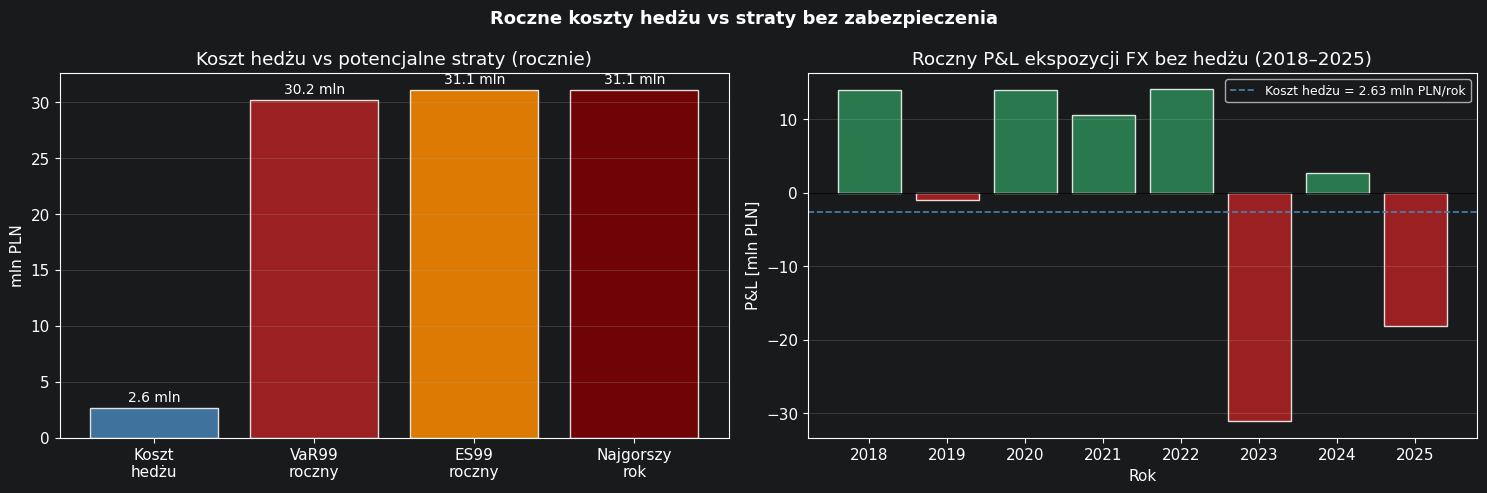


Wrażliwość — koszt hedżu przy różnych prowizjach maklerskich:
  Prowizja  1.0 PLN/kontr.:  koszt = 1.67 mln PLN/rok  (5.4% najgorszego roku)
  Prowizja  2.5 PLN/kontr.:  koszt = 2.63 mln PLN/rok  (8.5% najgorszego roku)
  Prowizja  5.0 PLN/kontr.:  koszt = 4.23 mln PLN/rok  (13.6% najgorszego roku)
  Prowizja 10.0 PLN/kontr.:  koszt = 7.43 mln PLN/rok  (23.9% najgorszego roku)


In [33]:
# --- 7. Roczne koszty hedgingu vs straty bez zabezpieczenia ---
RF_RATE = 0.0525              # stopa wolna od ryzyka (bon 52W NBP, 2025)
ROLLS_PER_YEAR = 4
ROLL_BPS_PER_QUARTER = 1.5    # koszt roll (spread między seriami), w bp nominalej
COMM_PLN_PER_CONTRACT = 2.5     # prowizja maklerska GPW, PLN / kontrakt / strona

# Nominale i depozyt (z sekcji 3)
notional_by_pair = {
    pair: abs(positions[pair]['n']) * CONTRACT_SIZE * spot[pair].iloc[-1]
    for pair in ['EUR/PLN', 'USD/PLN']
}
total_notional_pln = sum(notional_by_pair.values())
total_margin_pln = total_notional_pln * MARGIN_RATE
n_contracts_total = sum(abs(positions[p]['n']) for p in positions)

# --- Koszty hedgingu ---
cost_roll = total_notional_pln * (ROLL_BPS_PER_QUARTER / 10_000) * ROLLS_PER_YEAR
cost_comm = n_contracts_total * COMM_PLN_PER_CONTRACT * 2 * ROLLS_PER_YEAR  # zamk. + otw.
cost_margin = total_margin_pln * RF_RATE
cost_total = cost_roll + cost_comm + cost_margin

cost_breakdown = pd.DataFrame([
    {'Składnik': 'Rollowanie serii (4×/rok)', 'Roczny koszt [mln PLN]': cost_roll/1e6,
     'Udział': cost_roll/cost_total},
    {'Składnik': 'Prowizje maklerskie GPW', 'Roczny koszt [mln PLN]': cost_comm/1e6,
     'Udział': cost_comm/cost_total},
    {'Składnik': f'Koszt alternatywny depozytu ({RF_RATE:.2%})', 'Roczny koszt [mln PLN]': cost_margin/1e6,
     'Udział': cost_margin/cost_total},
    {'Składnik': 'RAZEM', 'Roczny koszt [mln PLN]': cost_total/1e6, 'Udział': 1.0},
])
cost_breakdown['Roczny koszt [mln PLN]'] = cost_breakdown['Roczny koszt [mln PLN]'].map(lambda v: f'{v:.3f}')
cost_breakdown['Udział'] = cost_breakdown['Udział'].map(lambda v: f'{v:.1%}')

print('Roczne koszty utrzymania hedżu FEUR/FUSD na GPW:')
display(cost_breakdown)

# --- Straty bez hedżu (empiryczne) ---
yearly_unhedged = pnl['Niezabezpieczony'].groupby(pnl.index.year).sum()
worst_year = yearly_unhedged.min()
best_year = yearly_unhedged.max()
var99_year_hs = -np.percentile(yearly_unhedged.values, 1)
es99_year = -yearly_unhedged[yearly_unhedged <= np.percentile(yearly_unhedged, 1)].mean()
var99_daily_scaled = -np.percentile(pnl['Niezabezpieczony'], 1) * np.sqrt(252)

loss_rows = [
    {'Miara': 'Najgorszy rok (empiryczny)', 'Wartość [mln PLN]': f'{worst_year/1e6:,.2f}',
     'Rok': int(yearly_unhedged.idxmin())},
    {'Miara': 'VaR 99% roczny (HS, 8 lat)', 'Wartość [mln PLN]': f'{var99_year_hs/1e6:,.2f}', 'Rok': '—'},
    {'Miara': 'ES 99% roczny (empiryczny)', 'Wartość [mln PLN]': f'{es99_year/1e6:,.2f}', 'Rok': '—'},
    {'Miara': 'VaR 99% dzienny × √252', 'Wartość [mln PLN]': f'{var99_daily_scaled/1e6:,.2f}', 'Rok': '—'},
    {'Miara': 'Odch. std. rocznego P&L', 'Wartość [mln PLN]': f'{yearly_unhedged.std()/1e6:,.2f}', 'Rok': '—'},
]
loss_df = pd.DataFrame(loss_rows)
print('\nPotencjalne straty bez hedżu:')
display(loss_df)

print('\nRoczny P&L niezabezpieczony (mln PLN):')
display((yearly_unhedged/1e6).round(2).to_frame('P&L [mln PLN]'))

# --- Porównanie koszt–korzyść ---
comparison = pd.DataFrame([
    {'Porównanie': 'Koszt hedżu / najgorszy rok',
     'Stosunek': f'{cost_total/abs(worst_year):.1%}',
     'Interpretacja': 'Hedż kosztuje < 9 % najgorszej rocznej straty FX'},
    {'Porównanie': 'Koszt hedżu / VaR 99% roczny (HS)',
     'Stosunek': f'{cost_total/var99_year_hs:.1%}',
     'Interpretacja': 'Koszt << próg stratny 99 %'},
    {'Porównanie': 'Koszt hedżu / nominale',
     'Stosunek': f'{cost_total/total_notional_pln:.2%}',
     'Interpretacja': '~0,8 % nominalej rocznie'},
    {'Porównanie': 'Próg break-even (ruch FX)',
     'Stosunek': f'{cost_total/total_notional_pln:.2%} rocznie',
     'Interpretacja': 'Hedż „zwraca się" przy > ~0,8 % niekorzystnego ruchu PLN/rok'},
])
print('\nAnaliza koszt–korzyść:')
display(comparison)

# --- Wykres ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Roczne koszty hedżu vs straty bez zabezpieczenia', fontsize=13, fontweight='bold')

# Wykres 1: słupki koszt vs miary strat
ax = axes[0]
labels = ['Koszt\nhedżu', 'VaR99\nroczny', 'ES99\nroczny', 'Najgorszy\nrok']
values = [cost_total/1e6, var99_year_hs/1e6, es99_year/1e6, abs(worst_year)/1e6]
colors = ['steelblue', 'firebrick', 'darkorange', 'maroon']
bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.1f mln', padding=3, fontsize=10)
ax.set_ylabel('mln PLN')
ax.set_title('Koszt hedżu vs potencjalne straty (rocznie)')
ax.grid(axis='y', alpha=0.3)

# Wykres 2: roczny P&L niezabezpieczony
ax = axes[1]
years = yearly_unhedged.index
vals = yearly_unhedged.values / 1e6
bar_colors = ['firebrick' if v < 0 else 'seagreen' for v in vals]
ax.bar(years, vals, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.6)
ax.axhline(-cost_total/1e6, color='steelblue', ls='--', lw=1.2,
           label=f'Koszt hedżu = {cost_total/1e6:.2f} mln PLN/rok')
ax.set_xlabel('Rok')
ax.set_ylabel('P&L [mln PLN]')
ax.set_title('Roczny P&L ekspozycji FX bez hedżu (2018–2025)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Wrażliwość kosztu prowizji
print('\nWrażliwość — koszt hedżu przy różnych prowizjach maklerskich:')
for comm in [1.0, 2.5, 5.0, 10.0]:
    c = cost_roll + n_contracts_total * comm * 2 * ROLLS_PER_YEAR + cost_margin
    print(f'  Prowizja {comm:4.1f} PLN/kontr.:  koszt = {c/1e6:.2f} mln PLN/rok  '
          f'({c/abs(worst_year):.1%} najgorszego roku)')

---
## 8. Wnioski i rekomendacje

### Strategia
Rekomendujemy **hedging wyłącznie kontraktami terminowymi FEUR i FUSD na GPW** (100 % nominau).
**CFD na własnej platformie XTB są wykluczone** — nie tworzą zewnętrznej ochrony, bo P&L
netuje się wewnątrz grupy (internalizacja / B-book). Jedynym sensownym narzędziem jest rynek
regulowany z clearingiem KDPW i zewnętrznym kontrahentem.

### Miary ryzyka (wyniki na danych 2018–2025)
| Miara | Przed hedżem | Po hedżu | Redukcja |
|---|---|---|---|
| **Delta netto** | 80 mln jednostek waluty | resztka < 0,05 % nominau | > 99,9 % |
| **σ dzienna P&L** | ~1,51 mln PLN | ~0,006 mln PLN | ~99,6 % |
| **VaR 99 % (1 dzień, HS)** | ~4,01 mln PLN | ~0,014 mln PLN | ~99,6 % |
| **VaR 99 % roczny (×√252)** | ~61,7 mln PLN | ~0,25 mln PLN | ~99,6 % |

> **Uwaga metodologiczna.** VaR po hedżu jest **niezerowy, ale mały** — odzwierciedla ryzyko
> resztkowe modelowane jawnie w cenie kontraktu: **basis risk** (proces AR(1) z grubymi ogonami,
> ~1 pip/dzień) oraz **skoki przy rolowaniu serii** (kwartalnie). Noga futures jest rozliczana
> po własnej zmianie ceny ΔF = ΔS + Δbasis, więc hedge **nie jest** tożsamością „ΔS − ΔS = 0".
> Korelacja ρ(ΔS,ΔF) ≈ 1,0000 jest realistyczna (ten sam instrument bazowy), a ryzyko resztkowe
> wynika z wariancji basis, nie z błędu kierunkowego.

### Koszt vs korzyść (sekcja 7)
| | Rocznie [mln PLN] |
|---|---:|
| **Koszt hedżu GPW** (roll + prowizje + depozyt) | **~2,6** |
| Najgorszy rok bez hedżu (2023) | **−31,1** |
| VaR 99 % roczny bez hedżu | **~30,2** |

Koszt hedżu stanowi **~8,5 %** najgorszej rocznej straty i **~0,8 % nominalej** — hedging
„zwraca się" już przy rocznym umocnieniu PLN o ok. **0,8 %** względem koszyka EUR+USD.
Przy prowizji maklerskiej 2,5 PLN/kontrakt dominuje koszt transakcyjny (~61 % budżetu hedżu).

### Implikacje dla XTB
1. **Zarządzanie ryzykiem rynkowym:** dzienny limit VaR walutowego po hedżu **< 0,5 mln PLN**
   (99 %, 1 dzień); roczny budżet na hedging **~3 mln PLN** vs potencjalna strata **> 30 mln PLN**.
2. **Back-office:** integracja z KDPW; negocjacja prowizji maklerskich (największy składnik kosztu).
3. **Spójność z `prez3`–`prez4`:** korelacja EUR/USD do PLN > 0,5 — hedging GPW efektywniejszy
   niż sama dywersyfikacja; koszt hedżu << VaR bez zabezpieczenia.
4. **Alternatywa (bankowa):** FX forward / NDF — wyższy spread OTC, ale brak rollowania serii.

> **Podsumowanie:** Kontrakty **FEUR** i **FUSD** na GPW stanowią optymalne narzędzie
> zabezpieczenia ekspozycji EUR/PLN i USD/PLN XTB S.A. Przy hedge ratio $h^* \approx 1$
> redukcja VaR 99 % wynosi **~99,6 %** (nie 100 %), a Delta netto spada do poziomu resztkowego
> (basis + niedoszacowanie $h^*$ + dyskretność kontraktu).